# Other Supporting Data

## Cited Number Plot

Draw the picture of the citation/article counts needed in the paper.

Create `pic_for_paper` folder first.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from brokenaxes import brokenaxes
from typing import Dict, Tuple, Optional
import matplotlib.ticker as ticker


def plot_citation_comparison_broken_axis(
    data_small: Dict,
    data_large: Dict,
    break_range: Tuple[float, float],
    label_small: str = "Small Dataset",
    label_large: str = "Large Dataset",
    figsize: Tuple[int, int] = (14, 7),
    x_tick_interval: int = 20,
    x_axis_padding: int = 5,
    title: str = "Citation Count Comparison with Broken Y-Axis",
) -> Tuple[plt.Figure, object]:
    """
    Generate a line chart with broken y-axis to compare two citation datasets with vastly different scales.

    Parameters:
    -----------
    data_small : dict
        Citation data dictionary for the smaller-scale dataset (e.g., citation_1).
        Must contain 'group_by' key with list of {'key': year_str, 'count': int}.
    data_large : dict
        Citation data dictionary for the larger-scale dataset (e.g., citation_2).
        Must contain 'group_by' key with list of {'key': year_str, 'count': int}.
    break_range : tuple (float, float)
        Y-axis break range (gap_start, gap_end). Data between these values will not be displayed.
        Example: (100, 1000) creates a gap between 100 and 1000 on the y-axis.
    label_small : str, optional
        Legend label for the smaller dataset (default: "Small Dataset").
    label_large : str, optional
        Legend label for the larger dataset (default: "Large Dataset").
    figsize : tuple, optional
        Figure dimensions (width, height) in inches (default: (14, 7)).
    x_tick_interval : int, optional
        Interval between publication year labels on the x-axis (default: 20).
    x_axis_padding : int, optional
        Number of years to pad on both sides of the x-axis range (default: 5).
    title : str, optional
        Chart title (default: "Citation Count Comparison with Broken Y-Axis").

    Returns:
    --------
    fig : matplotlib.figure.Figure
        The generated figure object.
    bax : brokenaxes.BrokenAxes
        The broken axes object for further customization if needed.

    Notes:
    ------
    - Years missing in either dataset are automatically set to count=0.
    - X-axis labels are intelligently sampled to avoid overcrowding.
    - Data points with y-values within break_range will NOT be visible (critical consideration).
    - Requires: pip install brokenaxes matplotlib numpy
    - Always validate that break_range avoids critical data regions (e.g., set gap between max of small dataset and min of large dataset's significant values).
    """

    # Validate break_range
    if break_range[0] >= break_range[1]:
        raise ValueError("break_range[0] must be strictly less than break_range[1]")

    # Extract and convert years to integers with counts
    def process_data(data: Dict) -> Dict[int, int]:
        return {
            int(item["key"]): item["count"]
            for item in data["group_by"]
            if item["key"].isdigit()  # Skip invalid year strings
        }

    dict_small = process_data(data_small)
    dict_large = process_data(data_large)

    # Create a continuous year axis covering both datasets.
    # This keeps each count aligned to its actual publication year, even when a
    # year is missing from one or both OpenAlex group_by responses.
    min_year = min(min(dict_small.keys()), min(dict_large.keys()))
    max_year = max(max(dict_small.keys()), max(dict_large.keys()))
    all_years = list(range(min_year, max_year + 1))

    # Generate count arrays with 0 for missing years
    counts_small = [dict_small.get(year, 0) for year in all_years]
    counts_large = [dict_large.get(year, 0) for year in all_years]

    # Calculate y-axis limits with padding
    global_max = max(max(counts_small), max(counts_large)) * 1.15
    lower_ylim = (0, break_range[0])
    upper_ylim = (
        break_range[1],
        global_max if global_max > break_range[1] else break_range[1] * 1.2,
    )

    # Create figure and broken y-axis
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    bax = brokenaxes(
        ylims=(lower_ylim, upper_ylim),
        hspace=0.08,  # Space between broken segments
        d=0.01,  # Size of diagonal break marks
        tilt=45,  # Angle of break marks
        fig=fig,
        height_ratios=[3, 1],
        despine=False,
    )

    # Plot both datasets
    bax.plot(
        all_years,
        counts_small,
        marker="o",
        markersize=4,
        linewidth=1.8,
        label=label_small,
        color="#1f77b4",
        alpha=0.9,
    )
    bax.plot(
        all_years,
        counts_large,
        marker="s",
        markersize=3,
        linewidth=1.5,
        label=label_large,
        color="#d62728",
        alpha=0.85,
        linestyle="--",
    )

    # Axis labels and legend
    # Never move it after the `set_yticklabels` function
    # Otherwise it will override the yticks settings
    bax.set_xlabel("Publication Year", fontsize=24, labelpad=30)
    bax.set_ylabel("Paper or Citation Count", fontsize=24, labelpad=80)
    bax.set_title(title, fontsize=24, pad=20)
    bax.legend(loc="upper left", fontsize=24, framealpha=0.9)

    # Add light grid for readability
    bax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, which="major")

    # Use fixed 20-year labels by default. Keep the axis slightly wider than
    # the data range so edge labels do not collide with the y-axis labels.
    x_min = all_years[0] - x_axis_padding
    x_max = all_years[-1] + x_axis_padding
    first_tick = (x_min // x_tick_interval) * x_tick_interval
    if first_tick < x_min:
        first_tick += x_tick_interval
    x_ticks = list(range(first_tick, x_max + 1, x_tick_interval))

    # Configure x-axis on the underlying axes explicitly. brokenaxes can apply
    # labels to both y-axis segments, so using fixed locators prevents year labels
    # from drifting away from the plotted data points.
    for i, ax in enumerate(bax.axs):
        ax.set_xlim(x_min, x_max)
        ax.xaxis.set_major_locator(ticker.FixedLocator(x_ticks))
        if i == len(bax.axs) - 1:
            ax.xaxis.set_major_formatter(
                ticker.FixedFormatter([str(int(year)) for year in x_ticks])
            )
            ax.tick_params(axis="x", which="major", labelsize=24, labelbottom=True)
        else:
            ax.tick_params(axis="x", which="major", labelbottom=False)

        ax.tick_params(axis="y", which="major", labelsize=24)
        if i == len(bax.axs) - 1:
            # Automatically generate 3 scales evenly distributed in the lower half of the range
            yticks = np.linspace(lower_ylim[0], lower_ylim[1], 3)
            ax.yaxis.set_major_locator(ticker.FixedLocator(yticks))
            # Format the lower half of the y-axis numbers.
            ax.set_yticklabels([f"{int(y)}" for y in yticks])

    # # Add warning annotation about break range
    warning_text = (
        f"Note: Y-axis broken between {break_range[0]:.0f} and {break_range[1]:.0f}. \n"
        f"Data values within this range are not visible."
    )
    fig.text(0.4, 0.55, warning_text,
             ha='center', fontsize=20, style='italic',
             color='darkred', alpha=0.85, wrap=True)

    return fig, bax

66
101510


/tmp/ipykernel_89849/1930835205.py:193: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'./pic_for_paper/1.1 - Comparison in the Topic Quantum Mechanics and Applications.pdf')
/tmp/ipykernel_89849/1930835205.py:193: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'./pic_for_paper/1.1 - Comparison in the Topic Quantum Mechanics and Applications.pdf')
/home/user/.conda/envs/tree/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


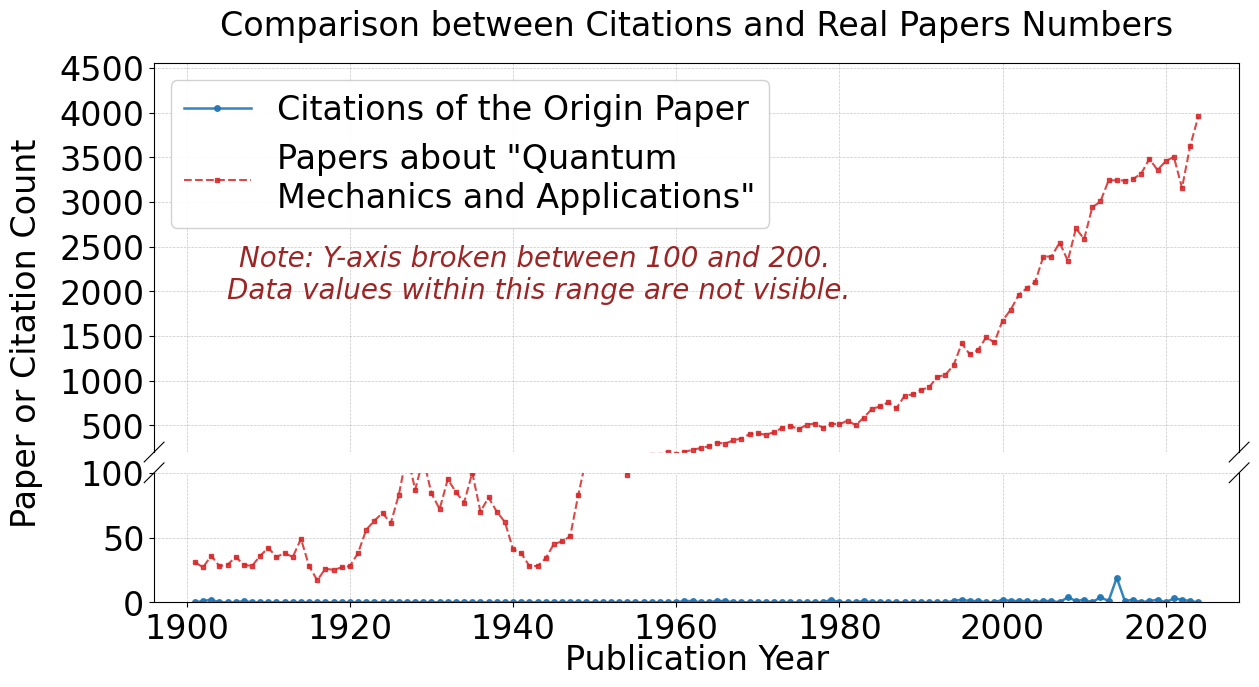

In [11]:
citation_1 = {
    "meta": {
        "count": 66,
        "db_response_time_ms": 60,
        "page": 1,
        "per_page": 200,
        "groups_count": 32,
    },
    "group_by": [
        {"key": "2014", "key_display_name": "2014", "count": 19},
        {"key": "2008", "key_display_name": "2008", "count": 4},
        {"key": "2012", "key_display_name": "2012", "count": 4},
        {"key": "2021", "key_display_name": "2021", "count": 3},
        {"key": "1903", "key_display_name": "1903", "count": 2},
        {"key": "1979", "key_display_name": "1979", "count": 2},
        {"key": "1995", "key_display_name": "1995", "count": 2},
        {"key": "2000", "key_display_name": "2000", "count": 2},
        {"key": "2010", "key_display_name": "2010", "count": 2},
        {"key": "2016", "key_display_name": "2016", "count": 2},
        {"key": "2019", "key_display_name": "2019", "count": 2},
        {"key": "2022", "key_display_name": "2022", "count": 2},
        {"key": "1902", "key_display_name": "1902", "count": 1},
        {"key": "1907", "key_display_name": "1907", "count": 1},
        {"key": "1961", "key_display_name": "1961", "count": 1},
        {"key": "1962", "key_display_name": "1962", "count": 1},
        {"key": "1965", "key_display_name": "1965", "count": 1},
        {"key": "1966", "key_display_name": "1966", "count": 1},
        {"key": "1983", "key_display_name": "1983", "count": 1},
        {"key": "1994", "key_display_name": "1994", "count": 1},
        {"key": "1996", "key_display_name": "1996", "count": 1},
        {"key": "1997", "key_display_name": "1997", "count": 1},
        {"key": "2001", "key_display_name": "2001", "count": 1},
        {"key": "2002", "key_display_name": "2002", "count": 1},
        {"key": "2003", "key_display_name": "2003", "count": 1},
        {"key": "2005", "key_display_name": "2005", "count": 1},
        {"key": "2006", "key_display_name": "2006", "count": 1},
        {"key": "2009", "key_display_name": "2009", "count": 1},
        {"key": "2013", "key_display_name": "2013", "count": 1},
        {"key": "2015", "key_display_name": "2015", "count": 1},
        {"key": "2018", "key_display_name": "2018", "count": 1},
        {"key": "2023", "key_display_name": "2023", "count": 1},
    ],
}

print(sum([i["count"] for i in citation_1["group_by"]]))

citation_2 = {
    "meta": {
        "count": 103666,
        "db_response_time_ms": 91,
        "page": 1,
        "per_page": 200,
        "groups_count": 200,
    },
    "group_by": [
        {"key": "2024", "key_display_name": "2024", "count": 3957},
        {"key": "2023", "key_display_name": "2023", "count": 3625},
        {"key": "2021", "key_display_name": "2021", "count": 3504},
        {"key": "2018", "key_display_name": "2018", "count": 3481},
        {"key": "2020", "key_display_name": "2020", "count": 3455},
        {"key": "2019", "key_display_name": "2019", "count": 3357},
        {"key": "2017", "key_display_name": "2017", "count": 3316},
        {"key": "2016", "key_display_name": "2016", "count": 3256},
        {"key": "2014", "key_display_name": "2014", "count": 3241},
        {"key": "2013", "key_display_name": "2013", "count": 3240},
        {"key": "2015", "key_display_name": "2015", "count": 3239},
        {"key": "2022", "key_display_name": "2022", "count": 3156},
        {"key": "2012", "key_display_name": "2012", "count": 3005},
        {"key": "2011", "key_display_name": "2011", "count": 2938},
        {"key": "2009", "key_display_name": "2009", "count": 2704},
        {"key": "2010", "key_display_name": "2010", "count": 2584},
        {"key": "2007", "key_display_name": "2007", "count": 2545},
        {"key": "2005", "key_display_name": "2005", "count": 2388},
        {"key": "2006", "key_display_name": "2006", "count": 2388},
        {"key": "2008", "key_display_name": "2008", "count": 2341},
        {"key": "2004", "key_display_name": "2004", "count": 2103},
        {"key": "2003", "key_display_name": "2003", "count": 2035},
        {"key": "2002", "key_display_name": "2002", "count": 1962},
        {"key": "2001", "key_display_name": "2001", "count": 1792},
        {"key": "2000", "key_display_name": "2000", "count": 1671},
        {"key": "1998", "key_display_name": "1998", "count": 1485},
        {"key": "1999", "key_display_name": "1999", "count": 1426},
        {"key": "1995", "key_display_name": "1995", "count": 1415},
        {"key": "1997", "key_display_name": "1997", "count": 1343},
        {"key": "1996", "key_display_name": "1996", "count": 1292},
        {"key": "1994", "key_display_name": "1994", "count": 1172},
        {"key": "1993", "key_display_name": "1993", "count": 1065},
        {"key": "1992", "key_display_name": "1992", "count": 1041},
        {"key": "1991", "key_display_name": "1991", "count": 925},
        {"key": "1990", "key_display_name": "1990", "count": 896},
        {"key": "1989", "key_display_name": "1989", "count": 844},
        {"key": "1988", "key_display_name": "1988", "count": 831},
        {"key": "1986", "key_display_name": "1986", "count": 757},
        {"key": "1985", "key_display_name": "1985", "count": 710},
        {"key": "1987", "key_display_name": "1987", "count": 691},
        {"key": "1984", "key_display_name": "1984", "count": 684},
        {"key": "1983", "key_display_name": "1983", "count": 586},
        {"key": "1981", "key_display_name": "1981", "count": 552},
        {"key": "1977", "key_display_name": "1977", "count": 519},
        {"key": "1979", "key_display_name": "1979", "count": 518},
        {"key": "1980", "key_display_name": "1980", "count": 510},
        {"key": "1976", "key_display_name": "1976", "count": 505},
        {"key": "1982", "key_display_name": "1982", "count": 500},
        {"key": "1974", "key_display_name": "1974", "count": 495},
        {"key": "1973", "key_display_name": "1973", "count": 472},
        {"key": "1978", "key_display_name": "1978", "count": 472},
        {"key": "1975", "key_display_name": "1975", "count": 455},
        {"key": "1972", "key_display_name": "1972", "count": 422},
        {"key": "1970", "key_display_name": "1970", "count": 408},
        {"key": "1969", "key_display_name": "1969", "count": 401},
        {"key": "1971", "key_display_name": "1971", "count": 394},
        {"key": "1968", "key_display_name": "1968", "count": 351},
        {"key": "1967", "key_display_name": "1967", "count": 331},
        {"key": "1965", "key_display_name": "1965", "count": 305},
        {"key": "1966", "key_display_name": "1966", "count": 294},
        {"key": "1964", "key_display_name": "1964", "count": 265},
        {"key": "1963", "key_display_name": "1963", "count": 244},
        {"key": "1962", "key_display_name": "1962", "count": 226},
        {"key": "1959", "key_display_name": "1959", "count": 202},
        {"key": "1961", "key_display_name": "1961", "count": 200},
        {"key": "1960", "key_display_name": "1960", "count": 175},
        {"key": "1958", "key_display_name": "1958", "count": 172},
        {"key": "1957", "key_display_name": "1957", "count": 163},
        {"key": "1953", "key_display_name": "1953", "count": 148},
        {"key": "1951", "key_display_name": "1951", "count": 141},
        {"key": "1956", "key_display_name": "1956", "count": 141},
        {"key": "1952", "key_display_name": "1952", "count": 127},
        {"key": "1955", "key_display_name": "1955", "count": 127},
        {"key": "1950", "key_display_name": "1950", "count": 116},
        {"key": "1927", "key_display_name": "1927", "count": 115},
        {"key": "1949", "key_display_name": "1949", "count": 112},
        {"key": "1929", "key_display_name": "1929", "count": 111},
        {"key": "1935", "key_display_name": "1935", "count": 100},
        {"key": "1954", "key_display_name": "1954", "count": 98},
        {"key": "1932", "key_display_name": "1932", "count": 95},
        {"key": "1928", "key_display_name": "1928", "count": 87},
        {"key": "1933", "key_display_name": "1933", "count": 85},
        {"key": "1930", "key_display_name": "1930", "count": 84},
        {"key": "1926", "key_display_name": "1926", "count": 83},
        {"key": "1948", "key_display_name": "1948", "count": 83},
        {"key": "1937", "key_display_name": "1937", "count": 81},
        {"key": "1934", "key_display_name": "1934", "count": 77},
        {"key": "1931", "key_display_name": "1931", "count": 72},
        {"key": "1936", "key_display_name": "1936", "count": 70},
        {"key": "1938", "key_display_name": "1938", "count": 70},
        {"key": "1924", "key_display_name": "1924", "count": 69},
        {"key": "1923", "key_display_name": "1923", "count": 63},
        {"key": "1939", "key_display_name": "1939", "count": 62},
        {"key": "1925", "key_display_name": "1925", "count": 61},
        {"key": "1922", "key_display_name": "1922", "count": 56},
        {"key": "1947", "key_display_name": "1947", "count": 51},
        {"key": "1914", "key_display_name": "1914", "count": 49},
        {"key": "1946", "key_display_name": "1946", "count": 47},
        {"key": "1945", "key_display_name": "1945", "count": 45},
        {"key": "1910", "key_display_name": "1910", "count": 42},
        {"key": "1940", "key_display_name": "1940", "count": 41},
        {"key": "1912", "key_display_name": "1912", "count": 38},
        {"key": "1921", "key_display_name": "1921", "count": 38},
        {"key": "1941", "key_display_name": "1941", "count": 38},
        {"key": "1903", "key_display_name": "1903", "count": 36},
        {"key": "1909", "key_display_name": "1909", "count": 36},
        {"key": "1906", "key_display_name": "1906", "count": 35},
        {"key": "1911", "key_display_name": "1911", "count": 35},
        {"key": "1913", "key_display_name": "1913", "count": 35},
        {"key": "1944", "key_display_name": "1944", "count": 34},
        {"key": "1901", "key_display_name": "1901", "count": 31},
        {"key": "1905", "key_display_name": "1905", "count": 29},
        {"key": "1907", "key_display_name": "1907", "count": 29},
        {"key": "1904", "key_display_name": "1904", "count": 28},
        {"key": "1908", "key_display_name": "1908", "count": 28},
        {"key": "1915", "key_display_name": "1915", "count": 28},
        {"key": "1920", "key_display_name": "1920", "count": 28},
        {"key": "1942", "key_display_name": "1942", "count": 28},
        {"key": "1943", "key_display_name": "1943", "count": 28},
        {"key": "1902", "key_display_name": "1902", "count": 27},
        {"key": "1919", "key_display_name": "1919", "count": 27},
        {"key": "1917", "key_display_name": "1917", "count": 26},
        {"key": "1918", "key_display_name": "1918", "count": 25},
        {"key": "1916", "key_display_name": "1916", "count": 17},
    ],
}

print(sum([i["count"] for i in citation_2["group_by"]]))

fig, ax = plot_citation_comparison_broken_axis(
    citation_1, 
    citation_2, 
    break_range=(100, 200),
    label_small="Citations of the Origin Paper",
    label_large='Papers about "Quantum \nMechanics and Applications"',
    title="Comparison between Citations and Real Papers Numbers"
)
plt.savefig(f'./pic_for_paper/1.1 - Comparison in the Topic Quantum Mechanics and Applications.pdf')

122
67456


/tmp/ipykernel_89849/213832092.py:140: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'./pic_for_paper/1.2 - Comparison in the Topic Advanced Graph Theory Research.pdf')
/tmp/ipykernel_89849/213832092.py:140: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(f'./pic_for_paper/1.2 - Comparison in the Topic Advanced Graph Theory Research.pdf')
/home/user/.conda/envs/tree/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


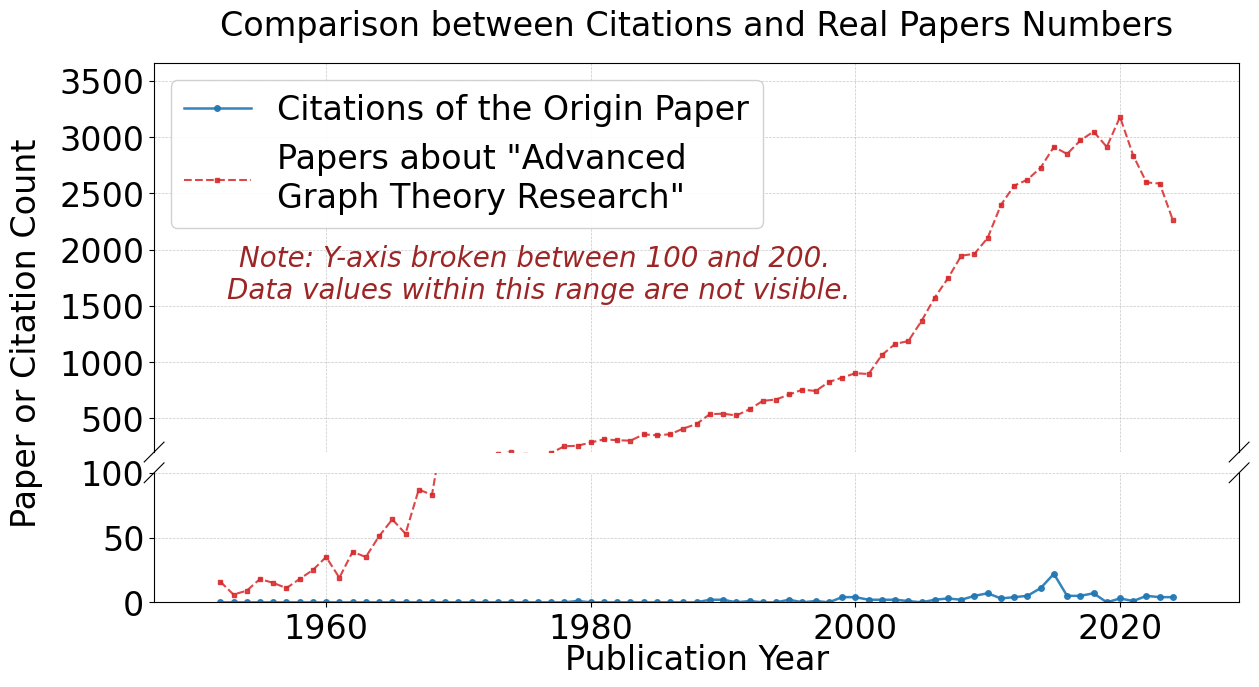

In [12]:
citation_1 = {
    "meta": {
        "count": 122,
        "db_response_time_ms": 287,
        "page": 1,
        "per_page": 200,
        "groups_count": 30,
    },
    "group_by": [
        {"key": "2015", "key_display_name": "2015", "count": 22},
        {"key": "2014", "key_display_name": "2014", "count": 11},
        {"key": "2010", "key_display_name": "2010", "count": 7},
        {"key": "2018", "key_display_name": "2018", "count": 7},
        {"key": "2009", "key_display_name": "2009", "count": 5},
        {"key": "2013", "key_display_name": "2013", "count": 5},
        {"key": "2016", "key_display_name": "2016", "count": 5},
        {"key": "2017", "key_display_name": "2017", "count": 5},
        {"key": "2022", "key_display_name": "2022", "count": 5},
        {"key": "1999", "key_display_name": "1999", "count": 4},
        {"key": "2000", "key_display_name": "2000", "count": 4},
        {"key": "2012", "key_display_name": "2012", "count": 4},
        {"key": "2023", "key_display_name": "2023", "count": 4},
        {"key": "2024", "key_display_name": "2024", "count": 4},
        {"key": "2007", "key_display_name": "2007", "count": 3},
        {"key": "2011", "key_display_name": "2011", "count": 3},
        {"key": "2020", "key_display_name": "2020", "count": 3},
        {"key": "1989", "key_display_name": "1989", "count": 2},
        {"key": "1990", "key_display_name": "1990", "count": 2},
        {"key": "1995", "key_display_name": "1995", "count": 2},
        {"key": "2001", "key_display_name": "2001", "count": 2},
        {"key": "2002", "key_display_name": "2002", "count": 2},
        {"key": "2003", "key_display_name": "2003", "count": 2},
        {"key": "2006", "key_display_name": "2006", "count": 2},
        {"key": "2008", "key_display_name": "2008", "count": 2},
        {"key": "1979", "key_display_name": "1979", "count": 1},
        {"key": "1992", "key_display_name": "1992", "count": 1},
        {"key": "1997", "key_display_name": "1997", "count": 1},
        {"key": "2004", "key_display_name": "2004", "count": 1},
        {"key": "2021", "key_display_name": "2021", "count": 1},
    ],
}

print(sum([i["count"] for i in citation_1["group_by"]]))

citation_2 = {
    "meta": {
        "count": 68076,
        "db_response_time_ms": 238,
        "page": 1,
        "per_page": 200,
        "groups_count": 168,
    },
    "group_by": [
        {"key": "2020", "key_display_name": "2020", "count": 3180},
        {"key": "2018", "key_display_name": "2018", "count": 3050},
        {"key": "2017", "key_display_name": "2017", "count": 2971},
        {"key": "2015", "key_display_name": "2015", "count": 2914},
        {"key": "2019", "key_display_name": "2019", "count": 2914},
        {"key": "2016", "key_display_name": "2016", "count": 2851},
        {"key": "2021", "key_display_name": "2021", "count": 2836},
        {"key": "2014", "key_display_name": "2014", "count": 2729},
        {"key": "2013", "key_display_name": "2013", "count": 2622},
        {"key": "2022", "key_display_name": "2022", "count": 2598},
        {"key": "2023", "key_display_name": "2023", "count": 2588},
        {"key": "2012", "key_display_name": "2012", "count": 2569},
        {"key": "2011", "key_display_name": "2011", "count": 2398},
        {"key": "2024", "key_display_name": "2024", "count": 2260},
        {"key": "2010", "key_display_name": "2010", "count": 2105},
        {"key": "2009", "key_display_name": "2009", "count": 1963},
        {"key": "2008", "key_display_name": "2008", "count": 1946},
        {"key": "2007", "key_display_name": "2007", "count": 1746},
        {"key": "2006", "key_display_name": "2006", "count": 1574},
        {"key": "2005", "key_display_name": "2005", "count": 1366},
        {"key": "2004", "key_display_name": "2004", "count": 1187},
        {"key": "2003", "key_display_name": "2003", "count": 1161},
        {"key": "2002", "key_display_name": "2002", "count": 1063},
        {"key": "2000", "key_display_name": "2000", "count": 901},
        {"key": "2001", "key_display_name": "2001", "count": 894},
        {"key": "1999", "key_display_name": "1999", "count": 862},
        {"key": "1998", "key_display_name": "1998", "count": 823},
        {"key": "1996", "key_display_name": "1996", "count": 755},
        {"key": "1997", "key_display_name": "1997", "count": 743},
        {"key": "1995", "key_display_name": "1995", "count": 712},
        {"key": "1994", "key_display_name": "1994", "count": 667},
        {"key": "1993", "key_display_name": "1993", "count": 655},
        {"key": "1992", "key_display_name": "1992", "count": 580},
        {"key": "1990", "key_display_name": "1990", "count": 541},
        {"key": "1989", "key_display_name": "1989", "count": 537},
        {"key": "1991", "key_display_name": "1991", "count": 525},
        {"key": "1988", "key_display_name": "1988", "count": 450},
        {"key": "1987", "key_display_name": "1987", "count": 409},
        {"key": "1986", "key_display_name": "1986", "count": 358},
        {"key": "1984", "key_display_name": "1984", "count": 357},
        {"key": "1985", "key_display_name": "1985", "count": 349},
        {"key": "1981", "key_display_name": "1981", "count": 313},
        {"key": "1982", "key_display_name": "1982", "count": 305},
        {"key": "1983", "key_display_name": "1983", "count": 301},
        {"key": "1980", "key_display_name": "1980", "count": 285},
        {"key": "1979", "key_display_name": "1979", "count": 256},
        {"key": "1978", "key_display_name": "1978", "count": 251},
        {"key": "1974", "key_display_name": "1974", "count": 199},
        {"key": "1977", "key_display_name": "1977", "count": 192},
        {"key": "1973", "key_display_name": "1973", "count": 180},
        {"key": "1975", "key_display_name": "1975", "count": 173},
        {"key": "1976", "key_display_name": "1976", "count": 167},
        {"key": "1972", "key_display_name": "1972", "count": 160},
        {"key": "1969", "key_display_name": "1969", "count": 142},
        {"key": "1970", "key_display_name": "1970", "count": 121},
        {"key": "1971", "key_display_name": "1971", "count": 118},
        {"key": "1967", "key_display_name": "1967", "count": 87},
        {"key": "1968", "key_display_name": "1968", "count": 83},
        {"key": "1965", "key_display_name": "1965", "count": 64},
        {"key": "1966", "key_display_name": "1966", "count": 53},
        {"key": "1964", "key_display_name": "1964", "count": 51},
        {"key": "1962", "key_display_name": "1962", "count": 39},
        {"key": "1960", "key_display_name": "1960", "count": 35},
        {"key": "1963", "key_display_name": "1963", "count": 35},
        {"key": "1959", "key_display_name": "1959", "count": 25},
        {"key": "1961", "key_display_name": "1961", "count": 19},
        {"key": "1955", "key_display_name": "1955", "count": 18},
        {"key": "1958", "key_display_name": "1958", "count": 18},
        {"key": "1952", "key_display_name": "1952", "count": 16},
        {"key": "1956", "key_display_name": "1956", "count": 15},
        {"key": "1957", "key_display_name": "1957", "count": 11},
        {"key": "1954", "key_display_name": "1954", "count": 9},
        {"key": "1953", "key_display_name": "1953", "count": 6},
    ],
}

print(sum([i["count"] for i in citation_2["group_by"]]))

fig, ax = plot_citation_comparison_broken_axis(
    citation_1, 
    citation_2, 
    break_range=(100, 200),
    label_small="Citations of the Origin Paper",
    label_large='Papers about "Advanced \nGraph Theory Research"',
    title="Comparison between Citations and Real Papers Numbers"
)
plt.savefig(f'./pic_for_paper/1.2 - Comparison in the Topic Advanced Graph Theory Research.pdf')